# ArgosQC SMRU Project Config


1. Connect to SMRU portal (requires user and password pair)
2. Download selected CIDs raw tag data (.mdb) from SMRU portal. 
3. Extract `deployments` table for observation.
3. Map tag locations for observation.
4. Generate configuration files for ArgosQC.smru_qc().

In [ ]:
from py_nrt import argos_smru_project_config as aspc
import itables

## 1. Download Tag .mdb files from SMRU portal

### OTN data team for `user` ,`password` and `cid`

In [ ]:
# Mandatory input
program = 'imos'
cid = 'ct182'
user = ''
password = ''

# (Optional) leave it blank if project is not in OTN node.
otn_collection_code = ''

# Destination folder for smru_qc config file and tag data download: {qc_input_path}/{program}_{cid}
qc_input_path = r'input'

# Destination folder for smru_qc results: {qc_output_path}/{program}_{cid}
qc_output_path = 'qc'

# Set to True to see API payload and response.
verbose=False

In [ ]:
aspc.smru_get_mdb(program, cid, user, password, qc_input_path, otn_collection_code, 120, True)

## 2. Extract `deployments` table for observation

### Requires `mdbtools` 
1. For Windows 
    - Download the `mdbtools-app` folder from https://github.com/apelsito/mdb-tools-for-windows/tree/main 
    - Save into `C:\mdbtools-app` and add to system path.
    - To test: in a `cmd` terminal type `mdb-tables --help`. Expected output:
    ```
        option parsing failed: Unrecognized option: --help.
        Usage:
          mdb-util [OPTIONa€|] <file> - show MDB files tables/entries
        ...
    ```
2. For Mac: need Mac user's help

In [ ]:
# Extract deployments table from each CIDs .mdb file.
cid_mdb, deployment_df = aspc.extract_deployments(program, cid, qc_input_path, verbose=verbose)
itables.show(deployment_df, buttons=['copy', 'csv'])

### If the preject has been create on OTN node, find matching tags in <project_schema>.otn_sat_tags and list tags to be excluded in `exclude_tag_ref`

In [ ]:
exclude_tag_ref = ['ct182-05-23']

## 3. Extract tracks (from the raw `ctd` table) for visualization


In [ ]:
cid_mdb, tracks_df = aspc.extract_tacks(program, cid, qc_input_path, exclude_tag_ref, verbose=verbose)
itables.show(tracks_df, buttons=['copy', 'csv'])

## 3. Visualize Tracks 

3.1 Click the `CSV` button 

3.2 Find downloaded `<cid>_tracks_<yyyymmdd>.csv`

3.3 Go to kepler.gl instance
https://kepler.gl/demo

3.4 Upload the `<cid>_tracks_<yyyymmdd>.csv`

3.5 Click `Add Layer`

3.6 Select `Basic` select `Point` 

3.7 Under `Color based on` select `tag_req`

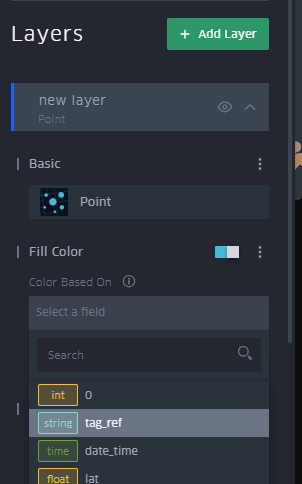

3.8 In Filters tab, click `Add Filter` select `date_time`

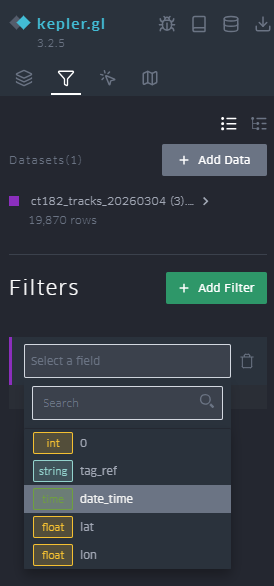

3.9 Adjust rolling window and click the play button
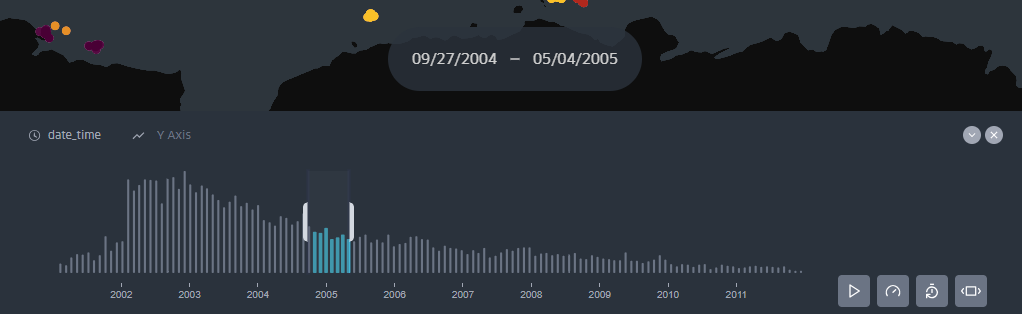

In [ ]:
aspc.export_for_kepler(cid, tracks_df)

In [ ]:
tracks_df.dtypes

## 4. Generate smru_qc Configuration Files

#### `time_step` (hours): adjust value (usually between 1 to 10) according to tagged animal's species.
#### `collection_code`: if project is found in OTN. Otherwise leave it blank.
#### `common_name` and `species` (scientific name): source 


In [ ]:
# Default settings
time_step = 3
# Set to empty string for Windows
mdb_tables_path = ''

# Project specific settings
common_name = 'southern elephant seal'
species = 'Mirounga leonina'
release_site = 'Iles Kerguelen'
state_country = 'French Overseas Territory'

output_files = aspc.create_smru_qc_config(
    program = program,
    cid = cid,
    drop_ids = exclude_tag_ref,
    otn_collection_code = otn_collection_code,
    qc_input_path = qc_input_path,
    qc_output_path=qc_output_path,
    mdb_tables_path=mdb_tables_path,
    user=user, 
    password=password, 
    time_step=time_step,
    common_name=common_name,
    species=species,
    release_site=release_site,
    state_country=state_country
)


### Next Step: Launch  `ArgosQC_SMRU` R-Notebook

- Replace config = "<smru_config_file.json>" with the above output path for `smru_qc config file`
```
library(ArgosQC)
library(pathroutr)
smru_qc(
  wd = ".",
  config = "<smru_config_file.json>"
)
```